# Load model

In [ ]:
from huggingface_hub import snapshot_download
import numpy as np
import torch
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    pipeline,
)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE, torch.__version__

In [164]:
MODEL_NAME = "microsoft/Phi-4-mini-instruct"
LOCAL_DIR = "Phi-4-mini-instruct"

_ = snapshot_download(
    repo_id=MODEL_NAME,
    local_dir=LOCAL_DIR,
    local_dir_use_symlinks=False,
    ignore_patterns=['*.bin']
)

Returning existing local_dir `Phi-4-mini-instruct` as remote repo cannot be accessed in `snapshot_download` ((ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 8ba14c4b-d40d-4442-a255-16612c47c36f)')).


In [165]:
from transformers import BitsAndBytesConfig
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

model = AutoModelForCausalLM.from_pretrained(
    LOCAL_DIR,
    device_map="auto",
    dtype="auto",
    quantization_config=bnb_config,
    trust_remote_code=False,
)
tokenizer = AutoTokenizer.from_pretrained(LOCAL_DIR)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

# LangChain

In [232]:
import os
import csv
import logging
import textwrap

import pandas as pd
import matplotlib.pyplot as plt

from datasets import Dataset
from dotenv import dotenv_values

from langchain_community.document_loaders.csv_loader import CSVLoader
from langchain_community.document_loaders import PyPDFLoader

from langchain_chroma import Chroma
from langchain_text_splitters import CharacterTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface.llms import HuggingFacePipeline
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableLambda
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser


csv.field_size_limit(10 * 1024 * 1024)
logging.getLogger("langchain_text_splitters").setLevel(logging.ERROR)

In [244]:
!gdown 1jPrwzO9Hk2wvWJdTkH08dcG9nbECRtjH

Downloading...
From (original): https://drive.google.com/uc?id=1jPrwzO9Hk2wvWJdTkH08dcG9nbECRtjH
From (redirected): https://drive.google.com/uc?id=1jPrwzO9Hk2wvWJdTkH08dcG9nbECRtjH&confirm=t&uuid=440466b9-376d-4b46-85bd-c23867982d4b
To: D:\HSE\rag\descriptions.csv

  0%|          | 0.00/180M [00:00<?, ?B/s]
  0%|          | 524k/180M [00:00<00:39, 4.59MB/s]
  1%|1         | 2.10M/180M [00:00<00:17, 10.4MB/s]
  4%|3         | 6.82M/180M [00:00<00:08, 20.6MB/s]
  9%|8         | 15.7M/180M [00:00<00:03, 42.4MB/s]
 11%|#1        | 20.4M/180M [00:00<00:03, 41.1MB/s]
 15%|#4        | 26.7M/180M [00:00<00:03, 46.2MB/s]
 18%|#7        | 32.0M/180M [00:00<00:03, 43.1MB/s]
 20%|##        | 36.7M/180M [00:00<00:03, 40.4MB/s]
 23%|##2       | 40.9M/180M [00:01<00:03, 38.4MB/s]
 25%|##5       | 45.1M/180M [00:01<00:03, 37.4MB/s]
 27%|##7       | 49.3M/180M [00:01<00:03, 37.1MB/s]
 30%|##9       | 53.5M/180M [00:01<00:03, 36.5MB/s]
 32%|###2      | 57.7M/180M [00:01<00:03, 36.1MB/s]
 34%|###4      |

In [245]:
loader = CSVLoader(
    file_path="descriptions.csv",
    encoding="utf-8",
    csv_args={
        "delimiter": ",",
    }
)
data = loader.load()

In [186]:
CHUNK_SIZE = 1024
CHUNK_OVERLAP = 128

text_splitter = CharacterTextSplitter(
    separator=",",
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,
    is_separator_regex=False,
)
texts = text_splitter.split_documents(data)
print(len(texts))

123472


In [187]:
texts_filtered = list(filter(lambda x: len(x.page_content) < CHUNK_SIZE * 2, texts))
print(len(texts_filtered))

121656


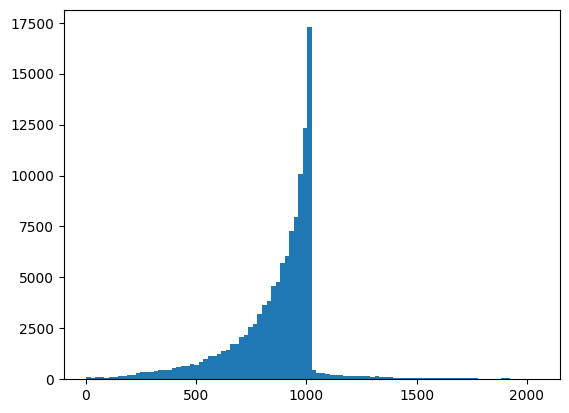

In [188]:
plt.hist(list(map(lambda x: len(x.page_content), texts_filtered)), bins=100)
plt.show()

In [193]:
EMBEDS_MODEL_NAME = 'intfloat/multilingual-e5-small'
embeddings = HuggingFaceEmbeddings(model_name=EMBEDS_MODEL_NAME)

In [235]:
db = Chroma.from_documents(
    texts,
    embeddings,
    persist_directory="chroma_langchain_db"
)

In [236]:
retriever = db.as_retriever(
    # search_type='mmr',
    search_type="similarity",
    search_kwargs={"k": 3}
)

In [237]:
QUESTION = 'У каких животных и какие побочные реакции могут возникать при применении адапален крема 0,1%?'


docs = retriever.invoke(QUESTION)
hits = []
for i, doc in enumerate(docs):
    print(f'Chunk {i} length: {len(doc.page_content)} chars')
    if 'адапален' in doc.page_content:
        hits.append(doc)
    print(doc.page_content)
    print('-' * 42)
hitrate = len(hits) / len(docs)
print(f'hitrate {hitrate}')
print(hits)

Chunk 0 length: 25 chars
1 до 1%) побочные реакции
------------------------------------------
Chunk 1 length: 4054 chars
15 до 5,0&nbsp;мг/кг/сут (до 120 раз превышающих МРДЧ при местном применении). </p>
<p class="OPIS_DVFLD">Однако пероральное введение животным доз &ge;25&nbsp;мг/кг/сут приводит к тератогенному действию у крыс и кроликов.</p>
<p class="OPIS_DVFLD">Тератологические исследования накожного применения адапалена у животных (крысы и кролики) показали, что при использовании доз 0,6; 2,0 и 6,0&nbsp;мг/кг (до 150 раз больше МРДЧ при местном применении) фетотоксического действия не наблюдается, но зафиксировано минимальное увеличение числа ребер у потомства крыс.</p>
<p class="OPIS_DVFLD"><i>Категория действия на плод по FDA&nbsp;&mdash;</i> C.</p>
<p class="OPIS_DVFLD">Кормящим женщинам следует соблюдать осторожность при использовании (неизвестно, проникает ли адапален в грудное молоко женщин, но многие ЛС экскретируются с молоком женщин).</p>
f9: <p class="OPIS_DVFLD_BEG"><i

In [238]:
generation_args = {
    'max_new_tokens': 128,
    'return_full_text': False,
    'do_sample': False,
    'use_cache': False,
}

pipe = pipeline(
    'text-generation',
    model=model,
    tokenizer=tokenizer,
    **generation_args,
)

llm = HuggingFacePipeline(pipeline=pipe)

Device set to use cuda:0


In [239]:
llm.invoke(QUESTION)

' Адапалин — это противогрибковый препарат, который используется для лечения грибковых инфекций кожи. При применении адапалин крема 0,1% могут возникать побочные реакции у некоторых животных, включая людей. К наиболее распространенным побочным эффектам относятся:\n\n1. Плагиальная дерматит — это аллергическая реакция, которая может проявляться в виде кожного отекания, покраснения, зудка и жжения. В редких случаях могут развиться анафилактический шок, который требует немедленного медицинского вмешательства.\n\n2. Поражение кожи — это ред'

In [240]:
template = """Ответь на вопрос используя контекст ниже:
{context}

Вопрос: {question}

Ответ:"""
prompt = PromptTemplate.from_template(template)

def format_docs(docs):
    return "\n".join([doc.page_content for doc in docs])

def format_newlines(text):
    return text.replace('\\n', '\n')

chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
    | RunnableLambda(format_newlines)
)

In [241]:
result = chain.invoke(QUESTION)

In [242]:
print(textwrap.fill(result, width=80))

 При применении адапален крема 0,1% у крыс и кроликов могут возникать побочные
реакции, такие как эритема, шелушение, сухость кожи, зуд, жжение. Эти побочные
эффекты наиболее вероятно в первые 2–4 нед лечения, затем их частота и
выраженность снижаются.


# [OUTDATED] Подготовка данных

In [ ]:
import sqlite3

In [ ]:
connection = sqlite3.connect('rls.sqlite')

In [ ]:
DB_NAME = 'descriptions'

In [ ]:
cursor = connection.cursor()
cursor.execute(f"""
SELECT * FROM {DB_NAME}
""")
data = cursor.fetchall()
print(len(data))

4867


In [ ]:
for item in data[5:10]:
    print(' '.join(item[5:]))
    print()

Состав и форма выпуска Состав Описание лекарственной формы Характеристика Фармакологическое действие Фармакодинамика Фармакокинетика Фармакологические (иммунобиологические) свойства Показания Противопоказания Применение при беременности и кормлении грудью Способ применения и дозы Побочные действия Взаимодействие Инструкция для пациента Передозировка Меры предосторожности Особые указания Форма выпуска   Производитель Литература Комментарий Инструкция Условия отпуска из аптек  

 <p class="OPIS_DVFLD_BEG">Синтетический карбоциклический нуклеозидный аналог. Абакавира сульфат&nbsp;&mdash; белое или почти белое вещество. Растворимость в дистиллированной воде при 25&nbsp;&deg;C&nbsp;&mdash; примерно 77 мг/мл. Коэффициент распределения октанол/вода (pH 7,0&ndash;7,3)&nbsp;&mdash; примерно 1,20 при 25&nbsp;&deg;C. Молекулярная масса 670,76 Да.</p> <p class="OPIS_DVFLD_BEG">Ингибирует обратную транскриптазу ВИЧ&minus;1 и ВИЧ&minus;2. Вызывает обрыв цепи РНК и прекращает репликацию вируса. Быстр

In [ ]:
connection.close()